Statistics & Probability - Titanic Dataset Analysis

## Objective
To understand statistical concepts used in data science through the analysis of the Titanic dataset.

## Task Breakdown
This notebook covers:
- Descriptive statistics (mean, variance, standard deviation, median)
- Probability distributions (visualization and quantification using skewness and kurtosis)
- Hypothesis testing (t-test and Chi-square test)
- Correlation analysis (though not causation)

## Dataset
This analysis utilizes the cleaned Titanic dataset, providing a foundation for exploring statistical relationships and patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Titanic = pd.read_csv("/content/Cleaned_Titanic.csv")
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


Descriptive Statistics
Calculating the selected statistical measures(mean,standard deviation and variance) individually since .describe function does not include variance.


In [3]:
mean_titanic = Titanic[["Pclass", "Age", "SibSp", "Parch", "Fare", "Has_Cabin"]].mean()
mean_titanic

,0
Pclass,2.308642
Age,29.066409
SibSp,0.523008
Parch,0.381594
Fare,32.204208
Has_Cabin,0.228956


In [4]:
std_titanic = Titanic[["Pclass", "Age", "SibSp", "Parch", "Fare", "Has_Cabin"]].std()
std_titanic

,0
Pclass,0.836071
Age,13.244532
SibSp,1.102743
Parch,0.806057
Fare,49.693429
Has_Cabin,0.420397


In [5]:
var_titanic = Titanic[["Pclass", "Age", "SibSp", "Parch", "Fare", "Has_Cabin"]].var()
var_titanic

,0
Pclass,0.699015
Age,175.417624
SibSp,1.216043
Parch,0.649728
Fare,2469.436846
Has_Cabin,0.176734


In [6]:
med_titanic = Titanic[["Pclass", "Age", "SibSp", "Parch", "Fare", "Has_Cabin"]].median()
med_titanic

,0
Pclass,3.0000
Age,26.0000
SibSp,0.0000
Parch,0.0000
Fare,14.4542
Has_Cabin,0.0000


In [7]:
# Combining individual variables into a dataframe
descriptive_stats = pd.concat([med_titanic,mean_titanic,std_titanic, var_titanic], axis=1)
descriptive_stats # 0=median, 1=mean, 2=standard deviation, 3=variance.

,0,1,2,3
Pclass,3.0000,2.308642,0.836071,0.699015
Age,26.0000,29.066409,13.244532,175.417624
SibSp,0.0000,0.523008,1.102743,1.216043
Parch,0.0000,0.381594,0.806057,0.649728
Fare,14.4542,32.204208,49.693429,2469.436846
Has_Cabin,0.0000,0.228956,0.420397,0.176734


Fare has the highest mean/average followed by Age
Fare has the has highest standard deviation and variance as well

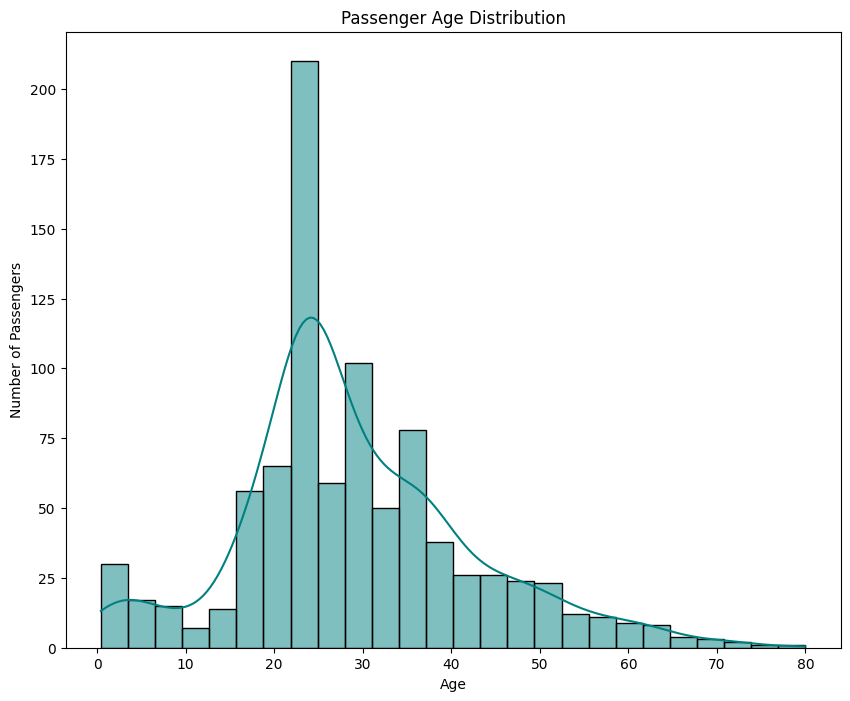

In [8]:
# Probability Distributions
plt.figure(figsize=(10,8))
sns.histplot(data=Titanic, x="Age", color="teal",kde=True)
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

Age distribution is slightly positively skewed, as evidenced by the mean age (29.07 years) being higher than the median age (26 years). This suggests the presence of older passengers whose ages increase the average age of the dataset.

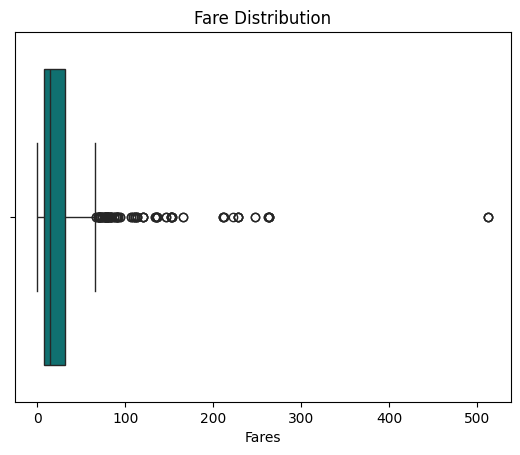

In [9]:
# plot six-Fare distribution
sns.boxplot(data=Titanic, x="Fare", color="teal")
plt.title("Fare Distribution")
plt.xlabel("Fares")
plt.show()

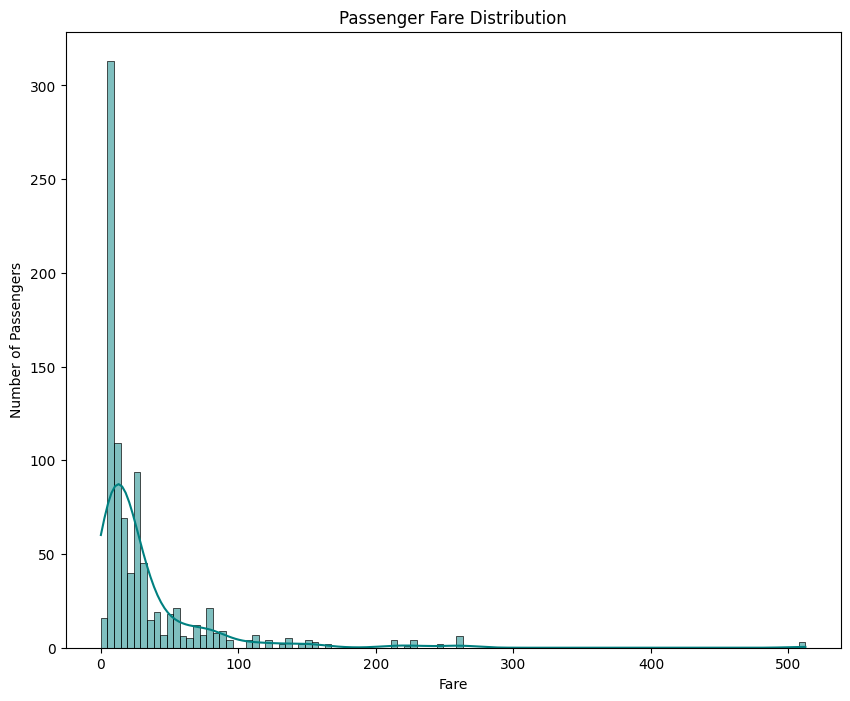

In [10]:
# Plotting the Fare distribution with a histogram and KDE
plt.figure(figsize=(10, 8))
sns.histplot(data=Titanic, x="Fare", kde=True, color="teal")
plt.title("Passenger Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

This histogram for 'Fare' visually confirms the highly positive skewness, with a large concentration of passengers paying lower fares and a long tail extending towards higher fares, representing the few who paid exceptionally high prices. The KDE (Kernel Density Estimate) overlay provides a smoothed representation of this distribution.

The Fare distribution is highly positively skewed, with a mean fare (32.20) substantially higher than the median fare (14.45). This indicates that while most passengers paid relatively low fares, a small number of passengers paid exceptionally high ticket prices, pulling the average upward.

In [11]:
sex_mapping={"male":0,"female":1}
Titanic["Sex"]=Titanic["Sex"].map(sex_mapping)
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,24.0,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C,1


In [12]:
# Calculating the correlation matrix
numeric_cols = Titanic[[
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Has_Cabin"
]]
correlation_matrix = numeric_cols.corr()

# Displaying correlation_matrix
correlation_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin
Survived,1.000000,-0.338481,0.543351,-0.047255,-0.035322,0.081629,0.257307,0.316912
Pclass,-0.338481,1.000000,-0.131900,-0.408487,0.083081,0.018443,-0.549500,-0.725541
Sex,0.543351,-0.131900,1.000000,-0.078421,0.114631,0.245489,0.182333,0.140391
Age,-0.047255,-0.408487,-0.078421,1.000000,-0.243526,-0.171095,0.123784,0.276032
SibSp,-0.035322,0.083081,0.114631,-0.243526,1.000000,0.414838,0.159651,-0.040460
Parch,0.081629,0.018443,0.245489,-0.171095,0.414838,1.000000,0.216225,0.036987
Fare,0.257307,-0.549500,0.182333,0.123784,0.159651,0.216225,1.000000,0.482075
Has_Cabin,0.316912,-0.725541,0.140391,0.276032,-0.040460,0.036987,0.482075,1.000000


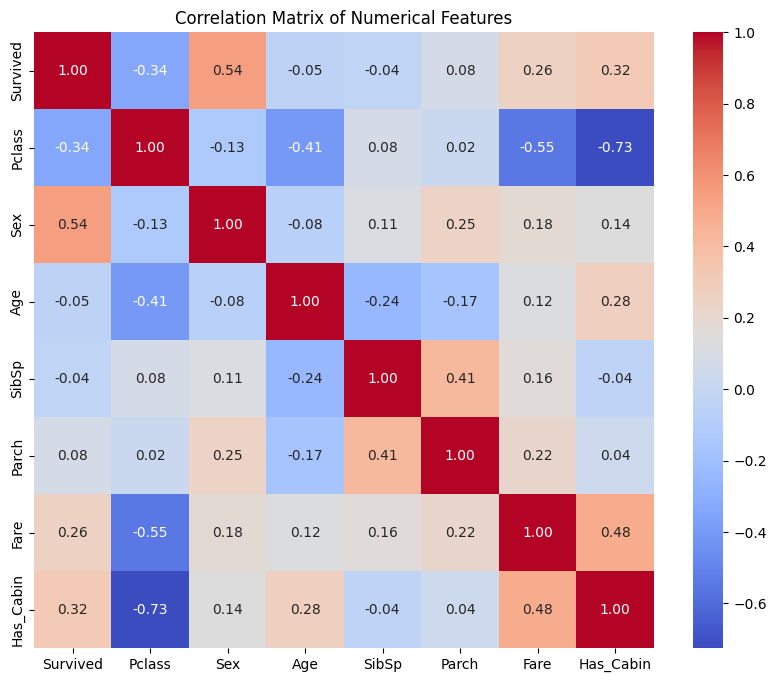

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Correlation Analysis

The correlation matrix revealed several notable relationships with passenger survival.

Sex and Survival (r = 0.54): Sex exhibited the strongest correlation with survival. Female passengers were more likely to survive than male passengers, reflecting the evacuation priorities during the disaster.

Pclass and Survival (r = -0.34): Passenger class showed a moderate negative correlation with survival. Since lower class numbers represent higher travel classes, first-class passengers had a higher likelihood of survival compared to third-class passengers.

Has_Cabin and Survival (r = 0.32): Passengers with recorded cabin information were more likely to survive. This may be associated with higher socioeconomic status and access to better accommodations rather than cabin assignment itself causing survival.

Fare and Survival (r = 0.26): Fare was positively correlated with survival, indicating that passengers who paid higher fares tended to have better survival outcomes. This relationship may also reflect the influence of passenger class.

Overall, Sex, Pclass, Has_Cabin, and Fare demonstrated the strongest relationships with survival, while Age, SibSp, and Parch showed relatively weak correlations

Visualizations

The bar chart below shows the survival rate by gender. Female passengers exhibited a substantially higher survival rate than male passengers, supporting the correlation analysis which identified Sex as the variable most strongly associated with survival.

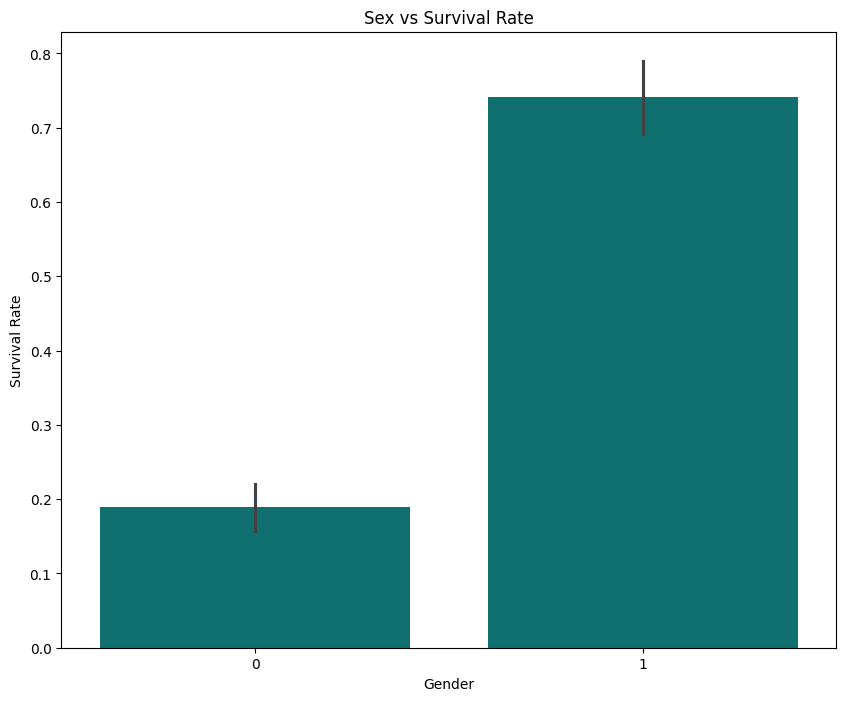

In [14]:
plt.figure(figsize=(10,8))
sns.barplot(data=Titanic,x="Sex",y="Survived",color="teal")
plt.title("Sex vs Survival Rate")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

Passenger class showed a moderate negative correlation with survival. Passengers in first-class had a higher likelihood of survival compared to third and second class passengers as shown in the plot below.


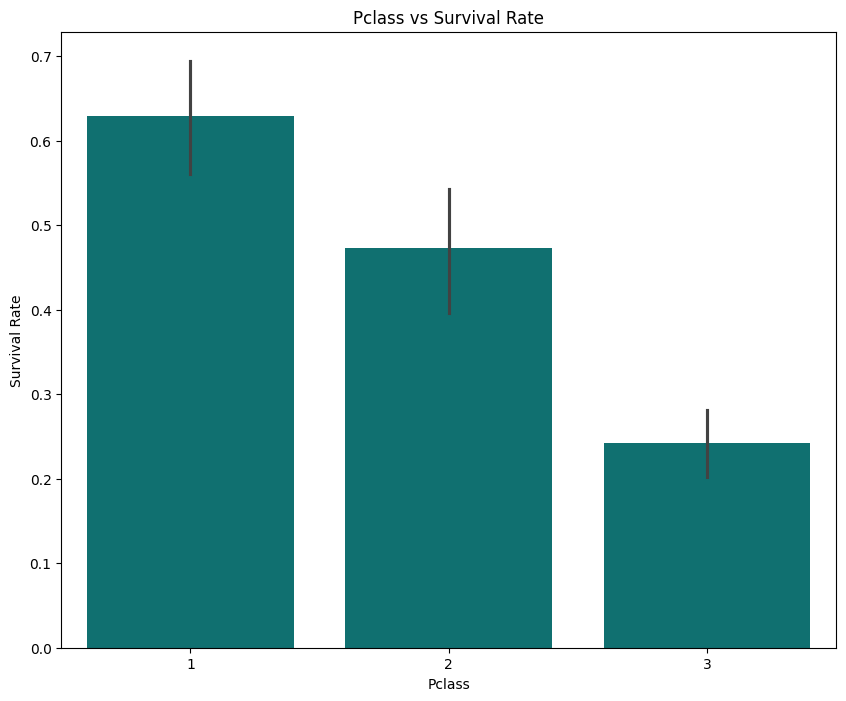

In [15]:
plt.figure(figsize=(10,8))
sns.barplot(data=Titanic,x="Pclass",y="Survived",color="teal")
plt.title("Pclass vs Survival Rate")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.show()

Survivors generally paid higher fares compared to non-survivors. The boxplot below shows a higher median fare among survivors, suggesting that passengers who paid higher fares were more likely to survive.

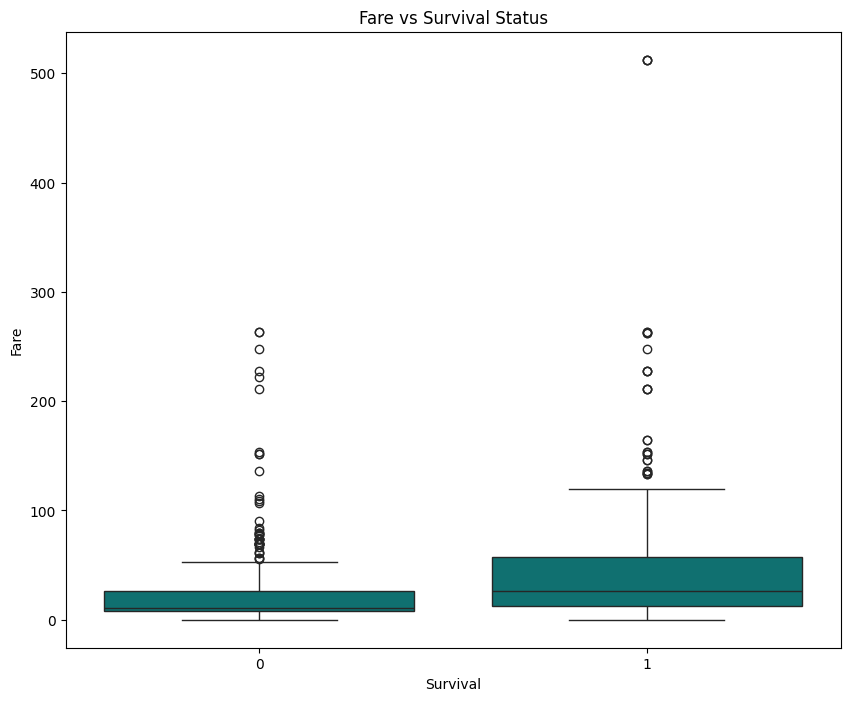

In [16]:
plt.figure(figsize=(10,8))
sns.boxplot(data=Titanic, x="Survived", y="Fare", color="teal")
plt.title("Fare vs Survival Status")
plt.xlabel("Survival")
plt.ylabel("Fare")
plt.show()

## Hypothesis Testing

To further investigate the relationship between 'Sex' and 'Survived',a hypothesis test can be performed.  An independent samples t-test is used to determine if there is a statistically significant difference in survival rates between male and female passengers.

In [17]:
from scipy import stats

# Separate survival rates by gender
survived_male = Titanic[Titanic['Sex'] == 0]['Survived']  # 0 for male
survived_female = Titanic[Titanic['Sex'] == 1]['Survived'] # 1 for female

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(survived_female, survived_male, equal_var=False)

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nBased on the t-test, there is a statistically significant difference in survival rates between female and male passengers.")
else:
    print("\nBased on the t-test, there is no statistically significant difference in survival rates between female and male passengers.")

T-statistic: 18.672
P-value: 0.000

Based on the t-test, there is a statistically significant difference in survival rates between female and male passengers.


### Interpretation of the T-test Results

The t-test results confirm the strong relationship observed in the correlation analysis and bar plot. The very low p-value (typically much less than 0.05) indicates that the difference in survival rates between female and male passengers is highly unlikely to have occurred by random chance. This provides strong statistical evidence that gender was a significant factor in survival during the Titanic disaster, with females having a significantly higher survival rate.

### Chi-square Test for Independence: Pclass and Survived

Chi-square test performed to investigate if there is a statistically significant association between passenger class ('Pclass') and survival ('Survived').

In [18]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(Titanic['Pclass'], Titanic['Survived'])

# Perform the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table (Pclass vs. Survived):\n")
display(contingency_table)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nBased on the Chi-square test, there is a statistically significant association between Pclass and Survived.")
else:
    print("\nBased on the Chi-square test, there is no statistically significant association between Pclass and Survived.")

Contingency Table (Pclass vs. Survived):



Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119



Chi-square statistic: 102.889
P-value: 0.000
Degrees of Freedom: 2

Based on the Chi-square test, there is a statistically significant association between Pclass and Survived.


### Interpretation of the Chi-square Test Results

Similar to the t-test for 'Sex', the Chi-square test for 'Pclass' yields a very low p-value (likely much less than 0.05). This result strongly indicates that there is a statistically significant association between a passenger's class and their survival outcome. This reinforces the earlier observation from the correlation analysis and bar plot that passengers in higher classes (lower `Pclass` number) had a significantly higher chance of survival.

## Correlation vs. Causation

While the analysis has identified several strong correlations (e.g., between 'Sex' and 'Survived', and 'Pclass' and 'Survived'), these do not necessarily imply direct causation.

*   **Correlation** describes a statistical relationship between two variables, indicating how they move together. A positive correlation means that as one variable increases, the other tends to increase, while a negative correlation means as one increases, the other tends to decrease. The correlation matrix and hypothesis tests showed strong statistical associations.

*   **Causation**, on the other hand, means that one event is the direct result of another. For causation to exist, there must be a cause-and-effect relationship where the change in one variable directly *produces* a change in another.

### Application to Titanic Data:

*   **'Sex' and 'Survived'**: a strong positive correlation and a statistically significant difference in survival rates between females and males were found. However, being female did not *directly cause* survival. Instead, social norms and evacuation protocols (women and children first) at the time of the disaster led to a higher survival rate for women. 'Sex' was a **proxy** for the social factors and policies that influenced who was prioritized during the rescue.

*   **'Pclass' and 'Survived'**: Similarly, 'Pclass' was strongly correlated with survival. While first-class passengers had a higher survival rate, it wasn't the class itself that caused survival. Rather, it was likely due to factors associated with class, such as better cabin locations (closer to lifeboats), preferential treatment during evacuation, and potentially better access to information. 'Pclass' acted as a **confounding variable** or a proxy for socioeconomic status and access to resources.

**Conclusion**: These statistical tests demonstrate strong relationships and associations, but they do not, on their own, establish causality. To infer causation, controlled experiments or more advanced causal inference techniques would be required, along with a deep understanding of the domain (in this case, the historical context of the Titanic disaster).